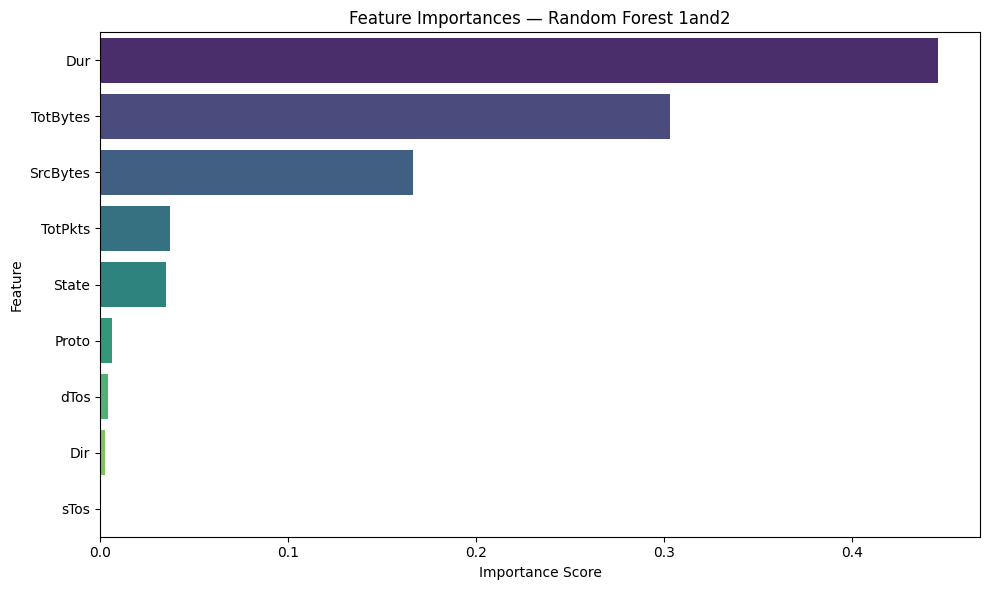

c:\Users\PC\Desktop\CSC 516\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


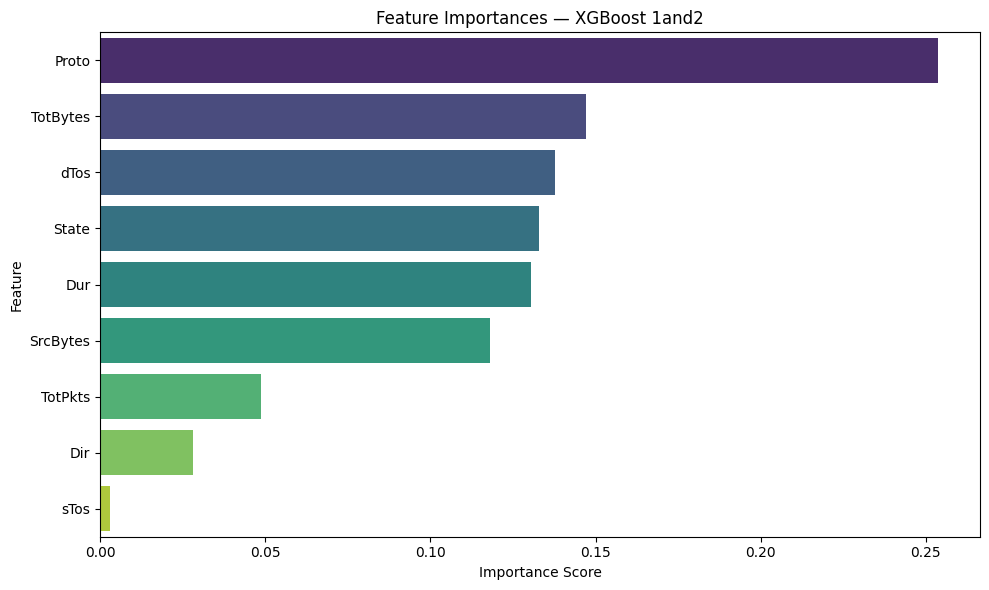

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.146921 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1151
[LightGBM] [Info] Number of data points in the train set: 3242930, number of used features: 9
[LightGBM] [Info] Start training from score -0.022133
[LightGBM] [Info] Start training from score -4.315364
[LightGBM] [Info] Start training from score -4.764426


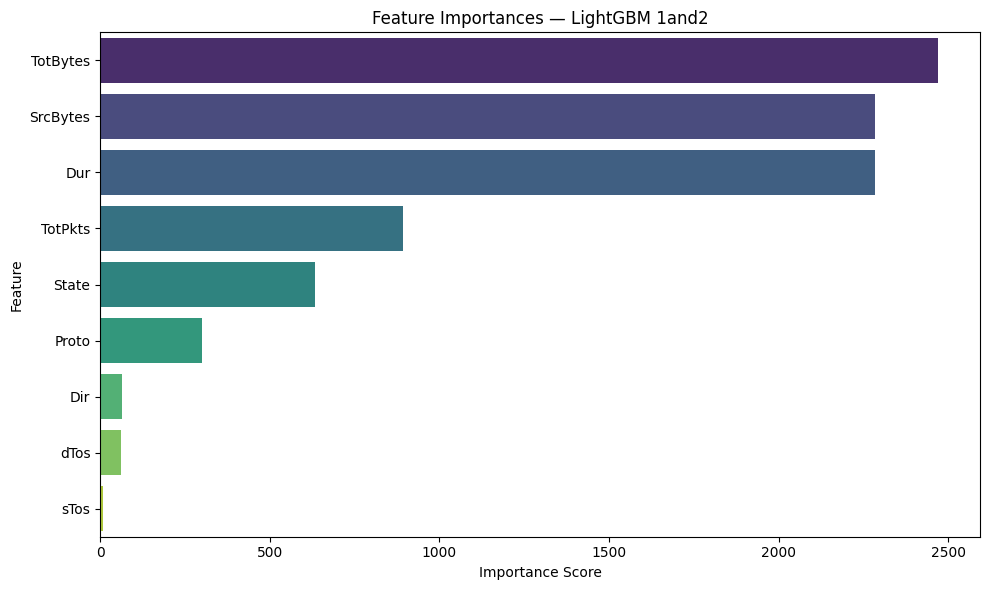


Random Forest 1and2 — Macro F1 Score: 0.7875
{'Background': {'precision': 0.9921087785350569, 'recall': 0.9959592615887097, 'f1-score': 0.9940302912609954, 'support': 1359405.0}, 'Botnet': {'precision': 0.8279997514447275, 'recall': 0.717516558074417, 'f1-score': 0.7688091391645511, 'support': 18571.0}, 'Normal': {'precision': 0.6922907002429866, 'recall': 0.5288558893013837, 'f1-score': 0.5996364679996173, 'support': 11852.0}, 'accuracy': 0.9882553812414198, 'macro avg': {'precision': 0.8374664100742569, 'recall': 0.7474439029881701, 'f1-score': 0.7874919661417211, 'support': 1389828.0}, 'weighted avg': {'precision': 0.9873591889412279, 'recall': 0.9882553812414198, 'f1-score': 0.987657605138053, 'support': 1389828.0}}


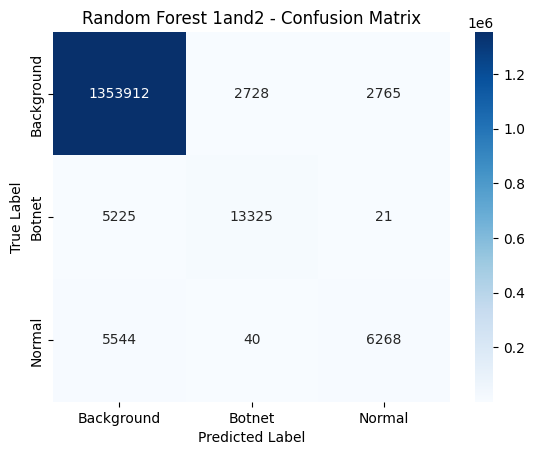


XGBoost 1and2 — Macro F1 Score: 0.7479
{'Background': {'precision': 0.9904839334050966, 'recall': 0.9956760494481042, 'f1-score': 0.9930732049468513, 'support': 1359405.0}, 'Botnet': {'precision': 0.7338375652800289, 'recall': 0.6582844219481988, 'f1-score': 0.6940107862617088, 'support': 18571.0}, 'Normal': {'precision': 0.7750828562820127, 'recall': 0.43410394870064123, 'f1-score': 0.5565170362358032, 'support': 11852.0}, 'accuracy': 0.986378890049704, 'macro avg': {'precision': 0.833134784989046, 'recall': 0.696021473365648, 'f1-score': 0.7478670091481211, 'support': 1389828.0}, 'weighted avg': {'precision': 0.9852177326460722, 'recall': 0.986378890049704, 'f1-score': 0.9853542988023749, 'support': 1389828.0}}


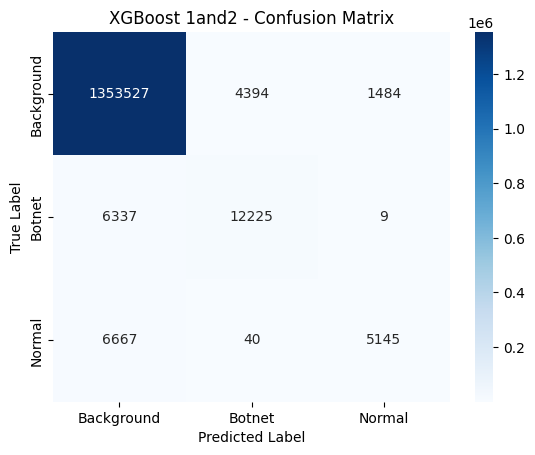


LightGBM 1and2 — Macro F1 Score: 0.7388
{'Background': {'precision': 0.9894558854141939, 'recall': 0.996516122862576, 'f1-score': 0.992973454376198, 'support': 1359405.0}, 'Botnet': {'precision': 0.7714369329821481, 'recall': 0.5677669484680415, 'f1-score': 0.6541145817177952, 'support': 18571.0}, 'Normal': {'precision': 0.7628632175761871, 'recall': 0.4541005737428282, 'f1-score': 0.5693129528745967, 'support': 11852.0}, 'accuracy': 0.9861615969745897, 'macro avg': {'precision': 0.841252011990843, 'recall': 0.6727945483578153, 'f1-score': 0.7388003296561966, 'support': 1389828.0}, 'weighted avg': {'precision': 0.9846103892342124, 'recall': 0.9861615969745897, 'f1-score': 0.9848327546723957, 'support': 1389828.0}}


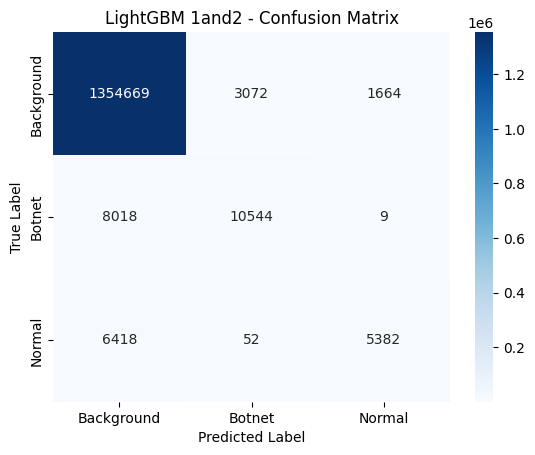

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from sklearn.preprocessing import label_binarize

import joblib

'''
This program is for training 3 ML models on the CTU-13 dataset
In this circumstance, the models will be trained and tested on a 70/30 split of scenarios 1 and 2
The 3 models are: Random Forest, LightGBM, and XGBoost
'''
# load scenarios into a dataframe
files = [
    "datasets/scenario1.binetflow",
    "datasets/scenario2.binetflow"
]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Function to clean label column
def extract_main_label(label):
    if 'Botnet' in label:
        return 'Botnet'
    elif 'Normal' in label:
        return 'Normal'
    elif 'Background' in label:
        return 'Background'
    return 'Unknown'

# Function to show the feature importance as a plot
def plot_feature_importance(model, model_name, X, top_n=15):
    importances = model.feature_importances_
    feat_names = X.columns
    feat_series = pd.Series(importances, index=feat_names).sort_values(ascending=False)[:top_n]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_series.values, y=feat_series.index, hue=feat_series.index, legend=False, palette='viridis')
    plt.title(f"Feature Importances — {model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Clean label column
df['Label'] = df['Label'].apply(extract_main_label)
df = df[df['Label'] != 'Unknown']

# Drop features
df = df.drop(columns=['StartTime', 'SrcAddr', 'DstAddr', 'Sport', 'Dport'])

# Encode categorical features using LabelEncoder
for col in df.select_dtypes(include='object').columns:
    if col != 'Label':
        df[col] = LabelEncoder().fit_transform(df[col])

# Prepare features and labels
X = df.drop(columns=['Label'])
y = LabelEncoder().fit_transform(df['Label'])  # 0=Background, 1=Botnet, 2=Normal

# Scale numeric features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
class_names = ['Background', 'Botnet', 'Normal']
y_bin = label_binarize(y, classes=[0, 1, 2])  # same order as label encoding
n_classes = y_bin.shape[1]




# Establish models
models = {
    'Random Forest 1and2': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost 1and2': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM 1and2': LGBMClassifier(random_state=42)
}


results = {}

# Loop to train each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # calculatemetrics
    f1 = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Background', 'Botnet', 'Normal'], output_dict=True)

    plot_feature_importance(model, name, X)

    #store results
    results[name] = {
        'model': model,
        'f1_macro': f1,
        'confusion_matrix': cm,
        'report': report
    }
    # Save models
    joblib.dump(model, f'models/{name.replace(" ", "_")}.joblib')

# Loop to print results
for name, res in results.items():
    print(f"\n{name} — Macro F1 Score: {res['f1_macro']:.4f}")
    #print(classification_report(y_test, res['model'].predict(X_test), target_names=['Background', 'Botnet', 'Normal']))
    print(res['report'])
    
    # Confusion matrix
    sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Background', 'Botnet', 'Normal'],
                yticklabels=['Background', 'Botnet', 'Normal'])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
